# Brain Tumor MRI Classification with Deep Learning

This notebook implements an end-to-end analytical pipeline for classifying brain MRI scans as tumor (`yes`) or no tumor (`no`). It uses the retained dataset folder `archive/brain_tumor_dataset`, removes exact duplicate images before splitting, compares three deep learning model variations, and produces report-ready evaluation outputs.

## 1. Objectives

The primary objective is to build a supervised image classification model that can identify whether a brain MRI scan shows evidence of a tumor. The analysis is designed as a proof-of-concept decision-support workflow rather than a clinical diagnostic system.

Specific objectives:

- Create a duplicate-safe modeling dataset from the retained `archive/brain_tumor_dataset` folder.
- Train and compare a baseline CNN, a frozen ResNet50 transfer-learning model, and a fine-tuned ResNet50 model.
- Evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.
- Recommend a final model based on validation performance, with emphasis on recall and F1-score.
- Produce report-ready findings, limitations, and next steps for a senior analytics audience.

Because the dataset is small, the main modeling strategy is transfer learning with ResNet50, supported by a simpler CNN baseline.

The notebook trains and compares three model variations:

1. Baseline CNN trained from scratch.
2. Frozen ResNet50 feature extractor.
3. Fine-tuned ResNet50 with the final residual block unfrozen.

Model selection emphasizes validation F1-score and recall because false negatives are especially important in a medical screening context.

## 2. Data Description

The dataset contains brain MRI image files organized into two binary class folders:

- `yes`: MRI scans labeled as showing a brain tumor.
- `no`: MRI scans labeled as not showing a brain tumor.

Only `archive/brain_tumor_dataset` is used for modeling because the project directory also contains a duplicated top-level copy of the same dataset. The raw retained dataset contains 253 images: 155 tumor images and 98 no-tumor images. Exact duplicate removal is performed before train/validation/test splitting, leaving 228 unique images: 141 tumor images and 87 no-tumor images.

The dataset includes image files only. It does not include patient demographics, scanner metadata, tumor type, tumor grade, tumor location annotations, segmentation masks, or clinical outcomes. As a result, this analysis is limited to binary image classification.

## 3. Environment Setup

Run the install cell only if TensorFlow is missing in your current environment.

In [ ]:
# Uncomment and run if TensorFlow is not installed.
# %pip install tensorflow

In [8]:
from pathlib import Path
import hashlib
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TensorFlow/Keras is required for model training. Run the previous install cell, "
        "restart the kernel, and rerun the notebook."
    ) from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "archive" / "brain_tumor_dataset"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
LABEL_MAP = {"no": 0, "yes": 1}
CLASS_NAMES = ["no", "yes"]

print(f"TensorFlow version: {tf.__version__}")
print(f"Dataset path: {DATA_DIR}")

TensorFlow version: 2.21.0
Dataset path: C:\Users\adrian\Documents\IBM_Projects\DeepLearning_Project\archive\brain_tumor_dataset


## 4. Dataset Inventory and Duplicate-Safe Cleaning

The project folder contains duplicate dataset layouts, so this notebook uses only `archive/brain_tumor_dataset`. Exact duplicates are identified by SHA-256 hash and removed from the modeling DataFrame before splitting. The original image files are not deleted.

In [9]:
def sha256_file(path: Path, block_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def inspect_image(path: Path) -> dict:
    record = {
        "path": str(path),
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "file_name": path.name,
        "extension": path.suffix.lower(),
        "file_size_bytes": path.stat().st_size,
        "label_name": path.parent.name,
        "label": LABEL_MAP.get(path.parent.name),
        "readable": False,
        "width": np.nan,
        "height": np.nan,
        "aspect_ratio": np.nan,
        "sha256": None,
        "error": None,
    }
    try:
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            record["width"], record["height"] = image.size
            record["aspect_ratio"] = record["width"] / record["height"]
        record["sha256"] = sha256_file(path)
        record["readable"] = True
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        record["error"] = repr(exc)
    return record


image_paths = sorted(
    [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)

metadata = pd.DataFrame([inspect_image(path) for path in image_paths])
metadata.to_csv(OUTPUT_DIR / "raw_image_metadata.csv", index=False)

print(f"Raw image files found: {len(metadata)}")
display(metadata.head())
display(metadata.groupby(["label_name", "readable"]).size().rename("count").reset_index())

Raw image files found: 253


,path,relative_path,file_name,extension,file_size_bytes,label_name,label,readable,width,height,aspect_ratio,sha256,error
0,C:\Users\adrian\Documents\IBM_Projects\DeepLea...,archive\brain_tumor_dataset\no\1 no.jpeg,1 no.jpeg,.jpeg,54521,no,0,True,630,630,1.000000,e4d9d83f89339366f4f77137d440a4c3b62e799a482ebf...,None
1,C:\Users\adrian\Documents\IBM_Projects\DeepLea...,archive\brain_tumor_dataset\no\10 no.jpg,10 no.jpg,.jpg,3848,no,0,True,173,201,0.860697,3c3bdbcf86cd640b0efb1f4a95726f65664a2b760cf385...,None
2,C:\Users\adrian\Documents\IBM_Projects\DeepLea...,archive\brain_tumor_dataset\no\11 no.jpg,11 no.jpg,.jpg,3475,no,0,True,300,168,1.785714,ab01efa9ce7ad51de522ba8cafa0de7d46ce3332215227...,None
3,C:\Users\adrian\Documents\IBM_Projects\DeepLea...,archive\brain_tumor_dataset\no\12 no.jpg,12 no.jpg,.jpg,4142,no,0,True,275,183,1.502732,91eb18f61d813028c6de3d9a78b79f807712662d006287...,None
4,C:\Users\adrian\Documents\IBM_Projects\DeepLea...,archive\brain_tumor_dataset\no\13 no.jpg,13 no.jpg,.jpg,4570,no,0,True,300,168,1.785714,c8280173142dbe052a428603990c3124edc9700d71fc33...,None


,label_name,readable,count
0,no,True,98
1,yes,True,155


In [10]:
invalid_labels = sorted(set(metadata["label_name"]) - set(LABEL_MAP))
if invalid_labels:
    raise ValueError(f"Unexpected label folders found: {invalid_labels}")

if not metadata["readable"].all():
    display(metadata.loc[~metadata["readable"], ["relative_path", "error"]])
    raise ValueError("Unreadable images found. Review the files above before training.")

cross_label_duplicates = (
    metadata.groupby("sha256")["label_name"]
    .nunique()
    .loc[lambda series: series > 1]
)

if len(cross_label_duplicates) > 0:
    duplicate_hashes = cross_label_duplicates.index.tolist()
    display(metadata.loc[metadata["sha256"].isin(duplicate_hashes), ["relative_path", "label_name", "sha256"]])
    raise ValueError("Exact duplicate images appear across both labels. Resolve labels before modeling.")

clean_metadata = (
    metadata.sort_values(["label_name", "relative_path"])
    .drop_duplicates(subset="sha256", keep="first")
    .reset_index(drop=True)
)

summary = pd.DataFrame(
    {
        "stage": ["raw", "deduplicated"],
        "total_images": [len(metadata), len(clean_metadata)],
        "yes_images": [int((metadata["label_name"] == "yes").sum()), int((clean_metadata["label_name"] == "yes").sum())],
        "no_images": [int((metadata["label_name"] == "no").sum()), int((clean_metadata["label_name"] == "no").sum())],
    }
)
summary["duplicates_removed"] = summary.loc[0, "total_images"] - summary["total_images"]

clean_metadata.to_csv(OUTPUT_DIR / "clean_image_metadata.csv", index=False)
summary.to_csv(OUTPUT_DIR / "dataset_cleaning_summary.csv", index=False)

display(summary)
print(f"Exact duplicate files removed from modeling DataFrame: {len(metadata) - len(clean_metadata)}")

,stage,total_images,yes_images,no_images,duplicates_removed
0,raw,253,155,98,0
1,deduplicated,228,141,87,25


Exact duplicate files removed from modeling DataFrame: 25


## 5. Exploratory Data Analysis

This section documents class balance, image-size variability, and examples from each class. These checks justify resizing, stratified splitting, class weighting, and duplicate-safe evaluation.

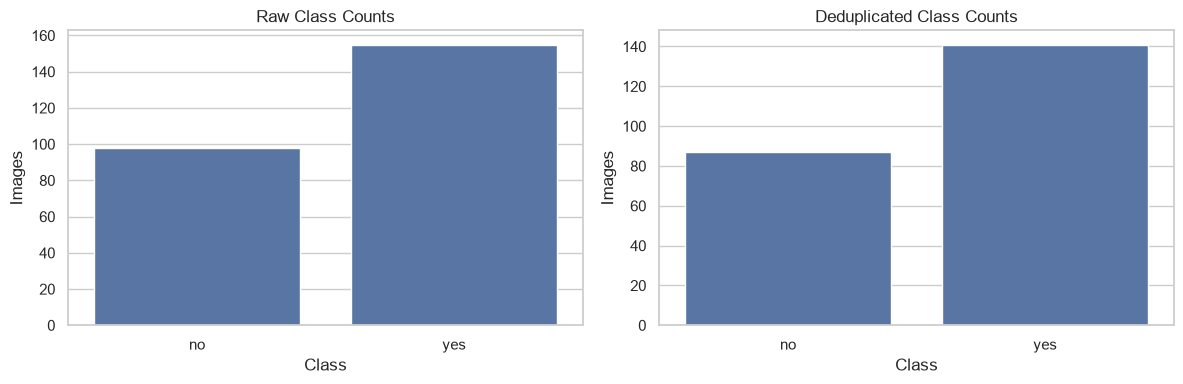

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=metadata, x="label_name", order=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Raw Class Counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Images")

sns.countplot(data=clean_metadata, x="label_name", order=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Deduplicated Class Counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Images")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_counts.png", dpi=160, bbox_inches="tight")
plt.show()

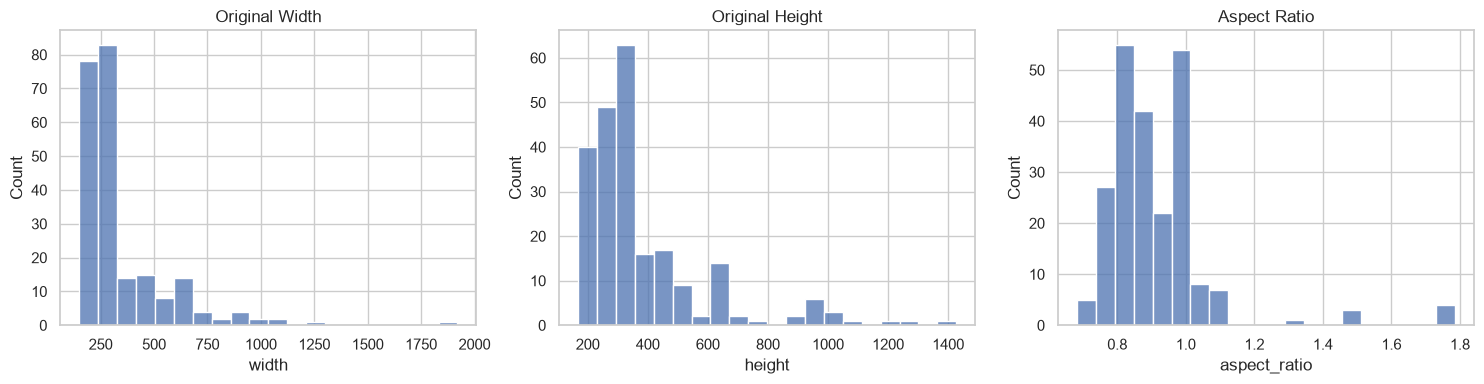

,width,height,aspect_ratio,file_size_bytes
count,228.000000,228.000000,228.000000,228.000000
mean,352.978070,384.956140,0.916865,34755.925439
std,219.290736,212.954128,0.165929,63043.406114
min,150.000000,168.000000,0.682454,3475.000000
25%,225.000000,246.750000,0.816138,7801.750000
50%,276.000000,332.500000,0.877640,20857.000000
75%,394.750000,442.000000,1.000000,31267.500000
max,1920.000000,1427.000000,1.785714,727906.000000


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(clean_metadata["width"], bins=20, ax=axes[0])
axes[0].set_title("Original Width")
sns.histplot(clean_metadata["height"], bins=20, ax=axes[1])
axes[1].set_title("Original Height")
sns.histplot(clean_metadata["aspect_ratio"], bins=20, ax=axes[2])
axes[2].set_title("Aspect Ratio")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "image_dimension_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

display(clean_metadata[["width", "height", "aspect_ratio", "file_size_bytes"]].describe())

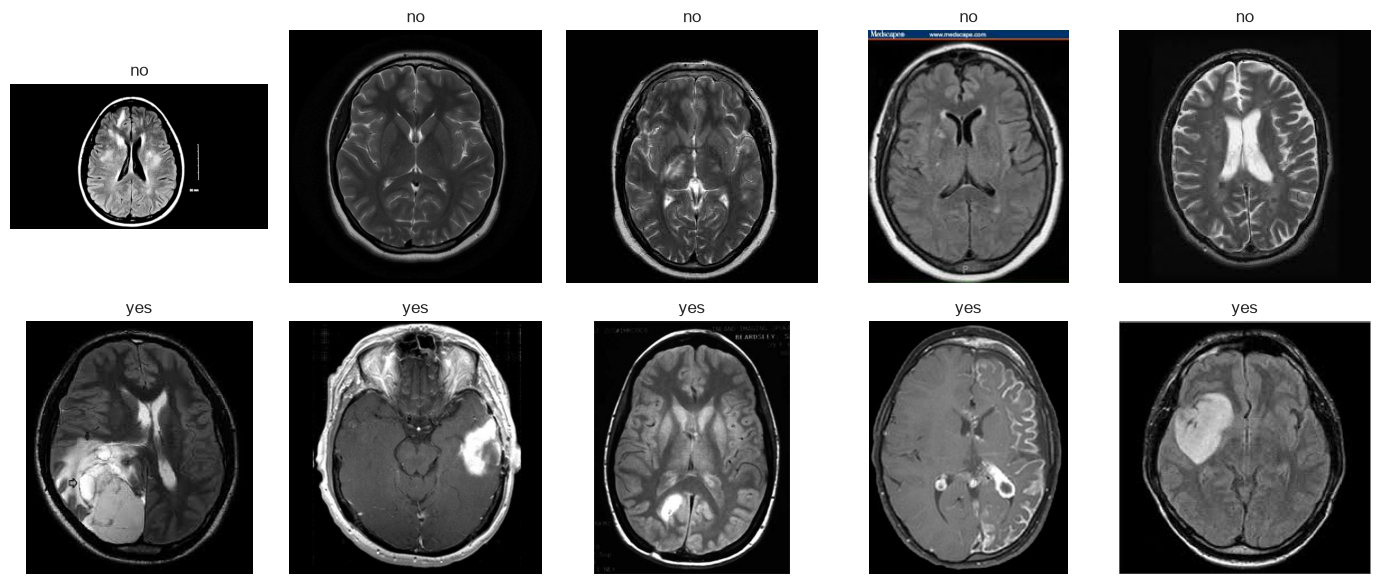

In [13]:
def show_samples(df: pd.DataFrame, n_per_class: int = 5) -> None:
    class_samples = {}
    for label_name in CLASS_NAMES:
        label_df = df.loc[df["label_name"] == label_name]
        if label_df.empty:
            raise ValueError(f"No images found for class: {label_name}")
        class_samples[label_name] = label_df.sample(
            n=min(n_per_class, len(label_df)),
            random_state=SEED,
        )

    fig, axes = plt.subplots(len(CLASS_NAMES), n_per_class, figsize=(14, 3 * len(CLASS_NAMES)))
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.axis("off")
    for row_idx, label_name in enumerate(CLASS_NAMES):
        label_samples = class_samples[label_name]
        for col_idx, (_, row) in enumerate(label_samples.iterrows()):
            with Image.open(row["path"]) as image:
                axes[row_idx, col_idx].imshow(ImageOps.exif_transpose(image).convert("RGB"), cmap="gray")
            axes[row_idx, col_idx].set_title(label_name)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "class_sample_images.png", dpi=160, bbox_inches="tight")
    plt.show()


show_samples(clean_metadata)

## 6. Split Strategy and TensorFlow Input Pipeline

Splitting happens after deduplication, with stratification by class. The notebook verifies that the same image hash does not appear in more than one split.

In [14]:
train_df, temp_df = train_test_split(
    clean_metadata,
    test_size=0.30,
    stratify=clean_metadata["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    split_df = split_df.copy().reset_index(drop=True)
    split_df.to_csv(OUTPUT_DIR / f"{split_name}_split.csv", index=False)
    print(f"{split_name}: {len(split_df)} images")
    display(split_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

split_hashes = {
    "train": set(train_df["sha256"]),
    "validation": set(val_df["sha256"]),
    "test": set(test_df["sha256"]),
}
assert split_hashes["train"].isdisjoint(split_hashes["validation"])
assert split_hashes["train"].isdisjoint(split_hashes["test"])
assert split_hashes["validation"].isdisjoint(split_hashes["test"])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(),
)
CLASS_WEIGHTS = {class_idx: float(weight) for class_idx, weight in zip([0, 1], class_weights_array)}
print(f"Class weights: {CLASS_WEIGHTS}")

train: 159 images


,class,count
0,yes,98
1,no,61


validation: 34 images


,class,count
0,yes,21
1,no,13


test: 35 images


,class,count
0,yes,22
1,no,13


Class weights: {0: 1.3032786885245902, 1: 0.8112244897959183}


In [15]:
augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomTranslation(0.05, 0.05, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="training_augmentation",
)


def load_image(path, label, model_family: str, training: bool = False):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image)

    if model_family == "cnn":
        image = image / 255.0
    elif model_family == "resnet":
        image = preprocess_input(image)
    else:
        raise ValueError(f"Unknown model family: {model_family}")

    return image, tf.cast(label, tf.float32)


def make_dataset(df: pd.DataFrame, model_family: str, training: bool = False):
    paths = df["path"].astype(str).to_numpy()
    labels = df["label"].astype(np.float32).to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(
        lambda path, label: load_image(path, label, model_family=model_family, training=training),
        num_parallel_calls=AUTOTUNE,
    )
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_cnn_ds = make_dataset(train_df, "cnn", training=True)
val_cnn_ds = make_dataset(val_df, "cnn", training=False)
test_cnn_ds = make_dataset(test_df, "cnn", training=False)

train_resnet_ds = make_dataset(train_df, "resnet", training=True)
val_resnet_ds = make_dataset(val_df, "resnet", training=False)
test_resnet_ds = make_dataset(test_df, "resnet", training=False)

## 7. Model Definitions

The baseline CNN provides a transparent reference point. The two ResNet50 variants test transfer learning with and without limited fine-tuning.

In [16]:
def compile_binary_model(model: keras.Model, learning_rate: float) -> keras.Model:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def build_baseline_cnn() -> keras.Model:
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="baseline_cnn")
    return compile_binary_model(model, learning_rate=1e-3)


def build_resnet_feature_extractor() -> keras.Model:
    base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="resnet50_frozen")
    return compile_binary_model(model, learning_rate=1e-3)


def prepare_resnet_for_fine_tuning(model: keras.Model) -> keras.Model:
    base_model = next(layer for layer in model.layers if isinstance(layer, keras.Model) and layer.name.startswith("resnet50"))
    base_model.trainable = True

    for layer in base_model.layers:
        layer.trainable = layer.name.startswith("conv5_")
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    return compile_binary_model(model, learning_rate=1e-5)


baseline_cnn = build_baseline_cnn()
resnet_frozen = build_resnet_feature_extractor()

baseline_cnn.summary()
resnet_frozen.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

...

Model: "resnet50_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. Training

Early stopping and checkpointing reduce overfitting risk. The final ResNet model is fine-tuned only after the frozen transfer-learning model has converged.

In [17]:
def training_callbacks(model_name: str):
    checkpoint_path = OUTPUT_DIR / f"{model_name}.keras"
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]


def train_model(model, train_ds, val_ds, model_name: str, epochs: int):
    print(f"Training {model_name}")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=CLASS_WEIGHTS,
        callbacks=training_callbacks(model_name),
        verbose=1,
    )
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)
    return history


history_baseline = train_model(baseline_cnn, train_cnn_ds, val_cnn_ds, "baseline_cnn", epochs=25)
history_resnet_frozen = train_model(resnet_frozen, train_resnet_ds, val_resnet_ds, "resnet50_frozen", epochs=25)

resnet_finetuned = keras.models.clone_model(resnet_frozen)
resnet_finetuned.set_weights(resnet_frozen.get_weights())
resnet_finetuned._name = "resnet50_finetuned"
resnet_finetuned = prepare_resnet_for_fine_tuning(resnet_finetuned)
history_resnet_finetuned = train_model(resnet_finetuned, train_resnet_ds, val_resnet_ds, "resnet50_finetuned", epochs=15)

Training baseline_cnn
Epoch 1/25
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5657 - auc: 0.5767 - loss: 0.7088 - precision: 0.5849 - recall: 0.8627
Epoch 1: val_loss improved from None to 0.67567, saving model to C:\Users\adrian\Documents\IBM_Projects\DeepLearning_Project\outputs\baseline_cnn.keras

Epoch 1: finished saving model to C:\Users\adrian\Documents\IBM_Projects\DeepLearning_Project\outputs\baseline_cnn.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5849 - auc: 0.5521 - loss: 0.6915 - precision: 0.6270 - recall: 0.8061 - val_accuracy: 0.6176 - val_auc: 0.7363 - val_loss: 0.6757 - val_precision: 0.6176 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5038 - auc: 0.4680 - loss: 0.7214 - precision: 0.5348 - recall: 0.8555
Epoch 2: val_loss improved from 0.67567 to 0.67497, saving model to C:\Users\adrian\Documents\IBM_Projects\DeepLearning_Project\outputs\baseline_cnn.keras

Epoch 2: finished savi

## 9. Evaluation and Model Selection

The validation set is used for model comparison. The test set is used once for the selected final model.

In [18]:
def predict_probabilities(model: keras.Model, dataset) -> np.ndarray:
    return model.predict(dataset, verbose=0).reshape(-1)


def evaluate_predictions(y_true, y_prob, threshold: float = 0.50) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
    }
    return metrics


def evaluate_model(model_name: str, model: keras.Model, dataset, df: pd.DataFrame) -> dict:
    y_true = df["label"].to_numpy().astype(int)
    y_prob = predict_probabilities(model, dataset)
    metrics = evaluate_predictions(y_true, y_prob)
    metrics["model"] = model_name
    return metrics


validation_results = pd.DataFrame(
    [
        evaluate_model("Baseline CNN", baseline_cnn, val_cnn_ds, val_df),
        evaluate_model("Frozen ResNet50", resnet_frozen, val_resnet_ds, val_df),
        evaluate_model("Fine-tuned ResNet50", resnet_finetuned, val_resnet_ds, val_df),
    ]
).sort_values(["f1", "recall", "roc_auc"], ascending=False)

validation_results.to_csv(OUTPUT_DIR / "model_validation_comparison.csv", index=False)
display(validation_results)

best_model_name = validation_results.iloc[0]["model"]
model_lookup = {
    "Baseline CNN": (baseline_cnn, test_cnn_ds),
    "Frozen ResNet50": (resnet_frozen, test_resnet_ds),
    "Fine-tuned ResNet50": (resnet_finetuned, test_resnet_ds),
}
best_model, best_test_ds = model_lookup[best_model_name]
print(f"Recommended model based on validation F1/recall: {best_model_name}")

,accuracy,precision,recall,f1,roc_auc,model
2,0.911765,0.909091,0.952381,0.930233,0.963370,Fine-tuned ResNet50
1,0.852941,0.863636,0.904762,0.883721,0.926740,Frozen ResNet50
0,0.647059,0.800000,0.571429,0.666667,0.721612,Baseline CNN


Recommended model based on validation F1/recall: Fine-tuned ResNet50


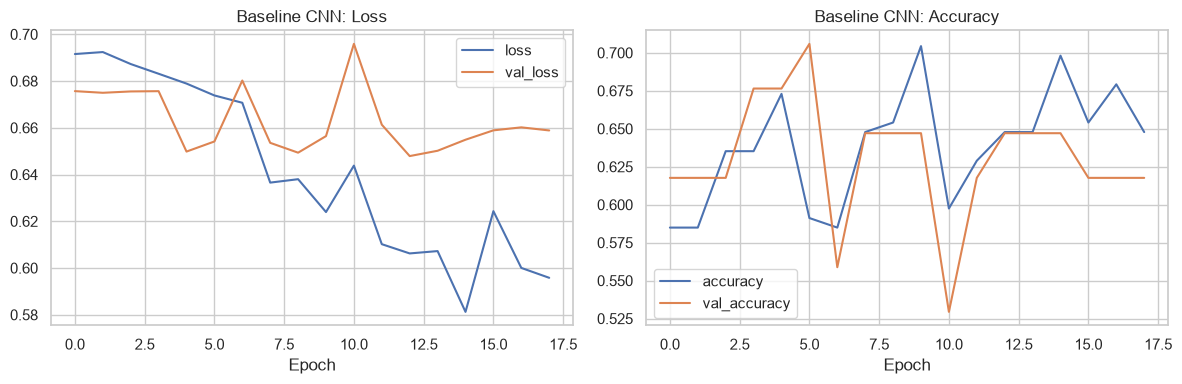

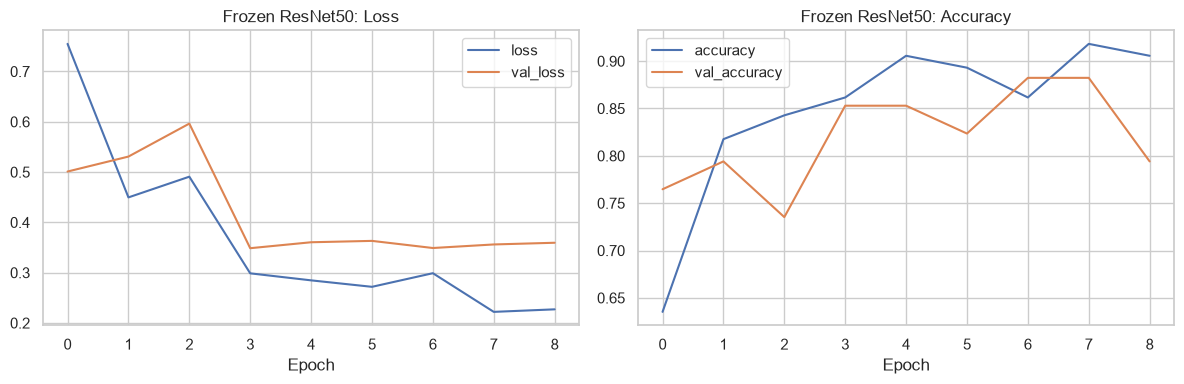

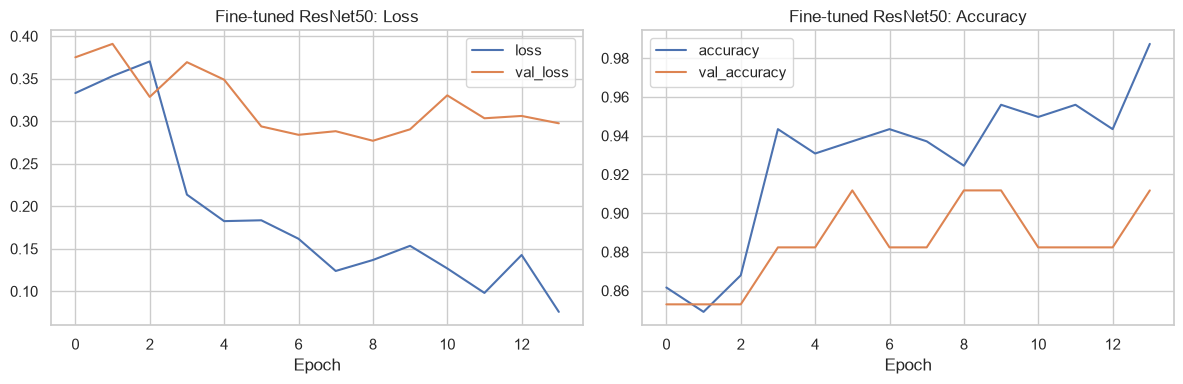

In [19]:
def plot_history(history, title: str):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{title.lower().replace(' ', '_')}_training_curves.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_history(history_baseline, "Baseline CNN")
plot_history(history_resnet_frozen, "Frozen ResNet50")
plot_history(history_resnet_finetuned, "Fine-tuned ResNet50")

,model,accuracy,precision,recall,f1,roc_auc
0,Fine-tuned ResNet50,0.857143,0.84,0.954545,0.893617,0.891608


              precision    recall  f1-score   support

          no       0.90      0.69      0.78        13
         yes       0.84      0.95      0.89        22

    accuracy                           0.86        35
   macro avg       0.87      0.82      0.84        35
weighted avg       0.86      0.86      0.85        35



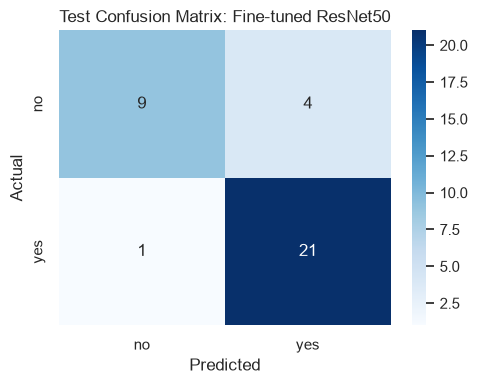

In [20]:
test_y_true = test_df["label"].to_numpy().astype(int)
test_y_prob = predict_probabilities(best_model, best_test_ds)
test_y_pred = (test_y_prob >= 0.50).astype(int)

test_metrics = pd.DataFrame([evaluate_predictions(test_y_true, test_y_prob)])
test_metrics.insert(0, "model", best_model_name)
test_metrics.to_csv(OUTPUT_DIR / "selected_model_test_metrics.csv", index=False)
display(test_metrics)

print(classification_report(test_y_true, test_y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(test_y_true, test_y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Test Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "selected_model_test_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

best_model.save(OUTPUT_DIR / "selected_brain_tumor_model.keras")

## 10. Explainability with Grad-CAM

Grad-CAM is used for the selected ResNet50 model when the selected model is ResNet-based. These visualizations are approximate explanations and should not be treated as clinical evidence.

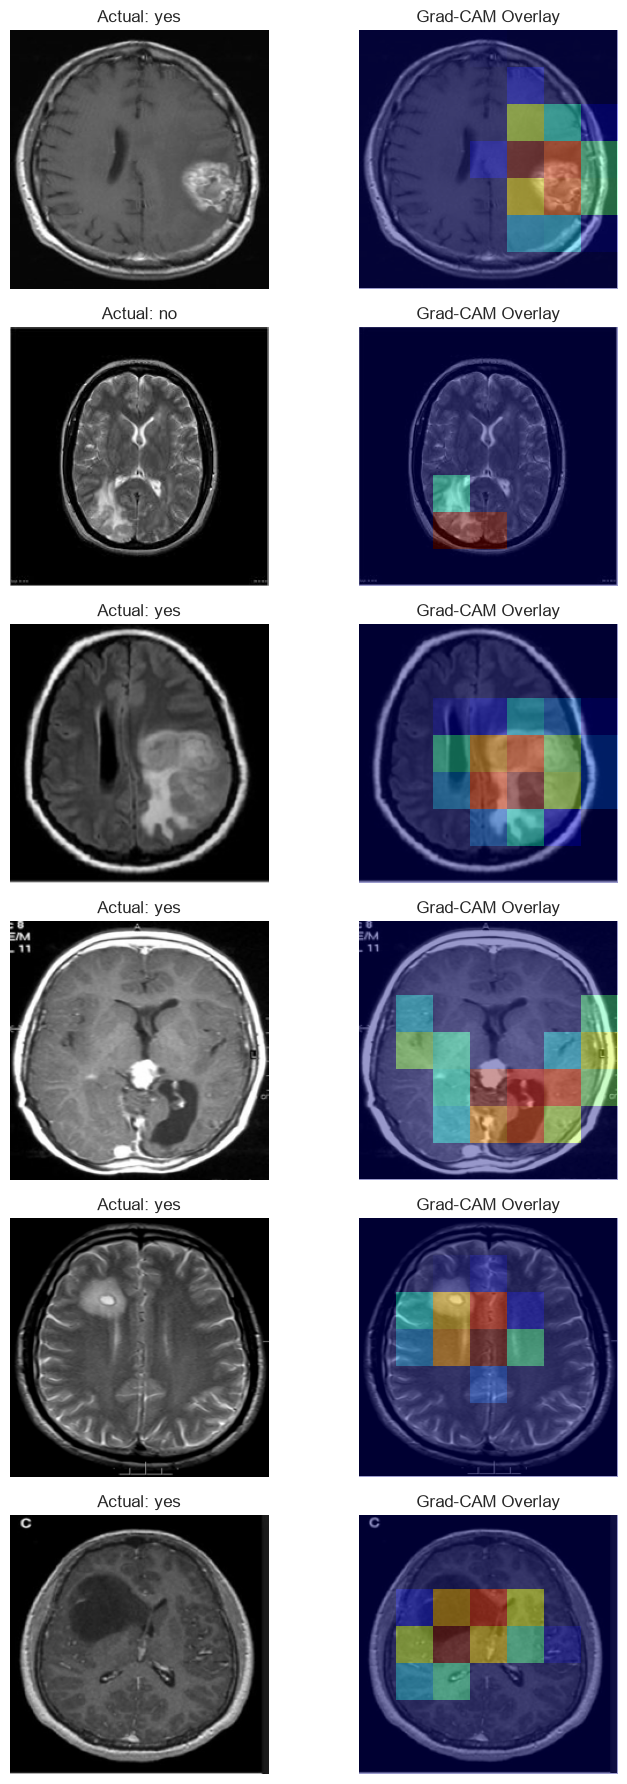

In [21]:
def find_last_conv_layer(model: keras.Model) -> str:
    for layer in reversed(model.layers):
        if isinstance(layer, keras.Model):
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, layers.Conv2D):
                    return sublayer.name
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found for Grad-CAM.")


def preprocess_single_image(path: str, model_family: str) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if model_family == "resnet":
        image = preprocess_input(image)
    else:
        image = image / 255.0
    return tf.expand_dims(image, axis=0)


def make_gradcam_heatmap(model: keras.Model, image_tensor: tf.Tensor, last_conv_layer_name: str) -> np.ndarray:
    base_model = model.get_layer("resnet50")
    conv_layer = base_model.get_layer(last_conv_layer_name)
    base_index = model.layers.index(base_model)
    head_layers = model.layers[base_index + 1:]
    activation_model = keras.Model(
        inputs=base_model.input,
        outputs=[conv_layer.output, base_model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, x = activation_model(image_tensor)
        for layer in head_layers:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)
        loss = x[:, 0]

    gradients = tape.gradient(loss, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    max_value = tf.math.reduce_max(heatmap)
    heatmap = tf.where(max_value > 0, tf.maximum(heatmap, 0) / max_value, tf.zeros_like(heatmap))
    return heatmap.numpy()


def plot_gradcam_examples(model: keras.Model, df: pd.DataFrame, model_name: str, max_examples: int = 6):
    if "ResNet50" not in model_name:
        print("Grad-CAM block is configured for ResNet50 models. Skipping for baseline CNN selection.")
        return

    last_conv_name = find_last_conv_layer(model.get_layer("resnet50"))
    example_df = df.copy().head(max_examples).reset_index(drop=True)
    fig, axes = plt.subplots(len(example_df), 2, figsize=(8, 3 * len(example_df)))
    if len(example_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, row in example_df.iterrows():
        image_tensor = preprocess_single_image(row["path"], "resnet")
        heatmap = make_gradcam_heatmap(model, image_tensor, last_conv_name)
        with Image.open(row["path"]) as raw_image:
            raw_image = ImageOps.exif_transpose(raw_image).convert("RGB").resize(IMG_SIZE)

        axes[idx, 0].imshow(raw_image)
        axes[idx, 0].set_title(f"Actual: {row['label_name']}")
        axes[idx, 0].axis("off")
        axes[idx, 1].imshow(raw_image)
        axes[idx, 1].imshow(heatmap, cmap="jet", alpha=0.40, extent=(0, IMG_SIZE[0], IMG_SIZE[1], 0))
        axes[idx, 1].set_title("Grad-CAM Overlay")
        axes[idx, 1].axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "gradcam_examples.png", dpi=160, bbox_inches="tight")
    plt.show()


plot_gradcam_examples(best_model, test_df, best_model_name)

## 11. Key Findings, Recommendation, Limitations, and Next Steps

Use the generated model comparison table, test metrics, confusion matrix, and Grad-CAM images to write the final analytical report.

Recommended interpretation structure:

- Compare the baseline CNN against transfer learning to show whether pretrained features improved generalization.
- Discuss the selected model using validation F1-score and recall, then report final untouched test-set performance.
- Highlight false negatives and false positives from the confusion matrix because these are more informative than accuracy alone.
- Use Grad-CAM cautiously to assess whether the model appears to focus on brain/tumor regions or irrelevant borders/artifacts.

Main limitations to include:

- The dataset is small after duplicate removal, with 228 unique images.
- The classes are imbalanced, with more tumor images than no-tumor images.
- There is no patient metadata, scanner metadata, tumor type, tumor grade, or external validation cohort.
- ResNet50 is pretrained on natural images, so there is a domain gap between ImageNet and MRI scans.
- The model is a proof of concept and should not be presented as a clinical diagnostic tool.

Recommended next steps:

- Validate the selected model on an independent external MRI dataset from a different source.
- Expand the dataset with more no-tumor examples and more diverse scanner/acquisition conditions.
- Add clinical metadata if available, including patient age, tumor type, tumor grade, and scanner protocol.
- Compare ResNet50 with one additional modern medical-imaging-friendly architecture if compute time allows.
- Review Grad-CAM outputs with a domain expert to assess whether the model is focusing on clinically plausible regions.
- Consider tumor localization or segmentation as a future extension if annotated masks become available.